In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
import mlflow
import mlflow.sklearn
import optuna
from mlflow.tracking import MlflowClient
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from lightgbm import LGBMClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
warnings.filterwarnings("ignore")

In [118]:
# pd.set_option('display.max_columns', None) # show all columns in the dataframe
# pd.set_option('display.max_rows', None) # show all rows in the dataframe

In [119]:
FILE_PATH = os.path.join(os.path.dirname(os.getcwd()), "data", "raw", "Telco-Customer-Churn.csv")

In [120]:
df = pd.read_csv(FILE_PATH)
df.shape

(7043, 21)

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [122]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [123]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [124]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [125]:
df.drop(columns=['customerID'], axis=0, inplace=True)

In [126]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [127]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [129]:
df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [130]:
cat_cols = []
num_cols = []
def cat_num_cols(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            cat_cols.append(col)
        else:
            num_cols.append(col)
    print(f"Categorical Columns:\n{cat_cols}")
    print()
    print(f"Numerical Columns:\n{num_cols}")

cat_num_cols(df)

Categorical Columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## Univariate Analysis

Distribution plot of SeniorCitizen


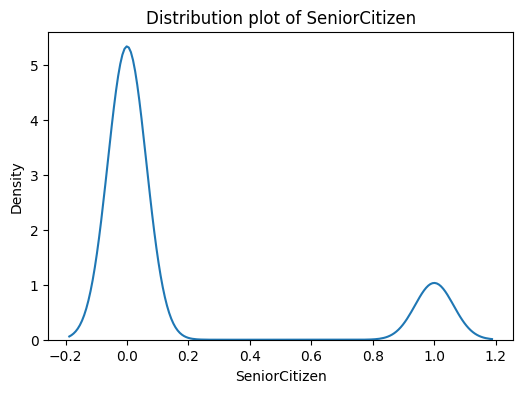

Distribution plot of tenure


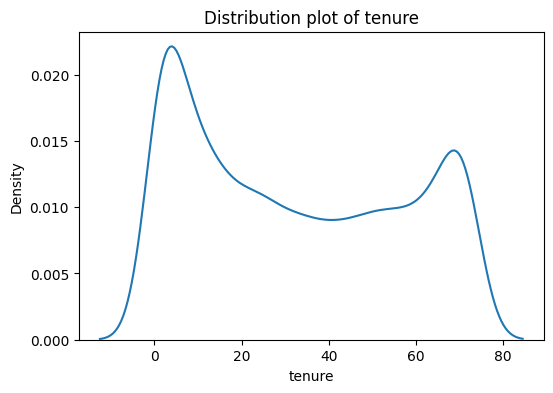

Distribution plot of MonthlyCharges


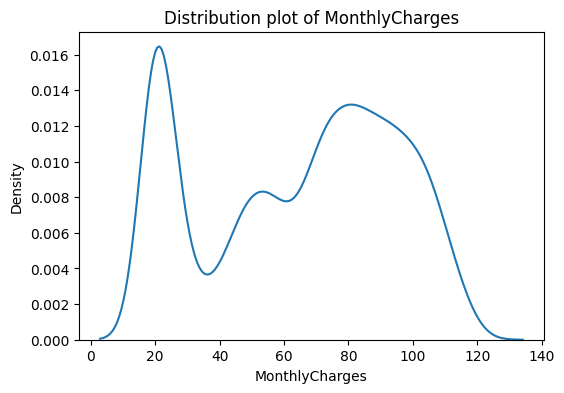

Distribution plot of TotalCharges


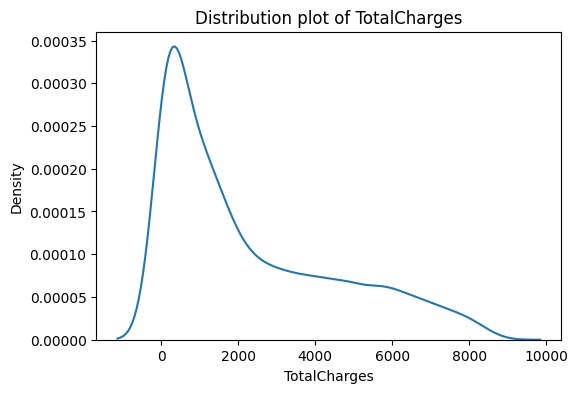

In [131]:
def dist_plot_num(df, num_cols):
    for col in num_cols:
        plt.figure(figsize=(6,4))
        print(f"Distribution plot of {col}")
        sns.kdeplot(df[col])
        plt.title(f"Distribution plot of {col}")
        plt.show()

dist_plot_num(df, num_cols)

Distribution plot of gender


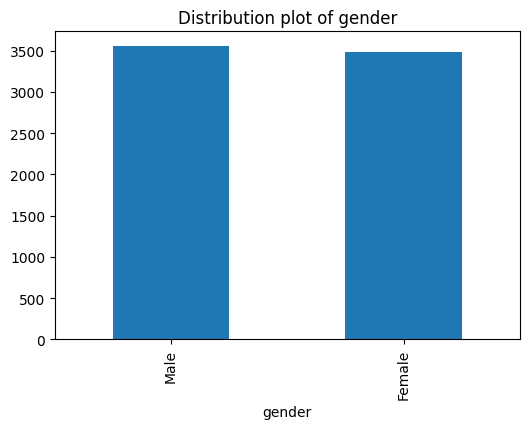

Distribution plot of Partner


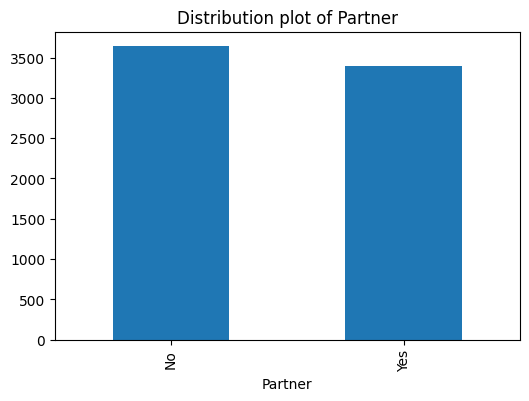

Distribution plot of Dependents


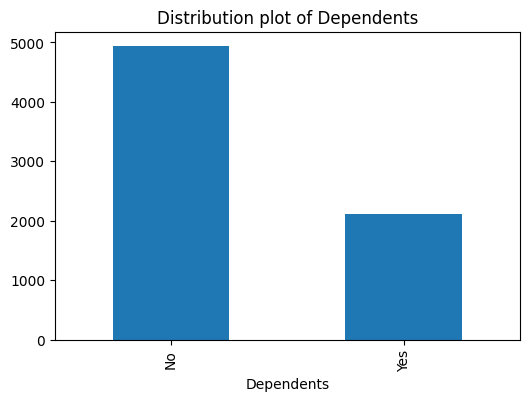

Distribution plot of PhoneService


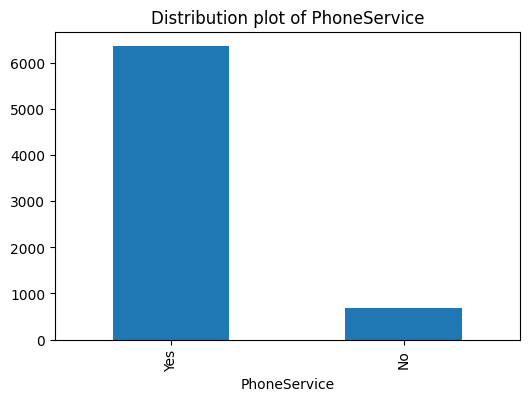

Distribution plot of MultipleLines


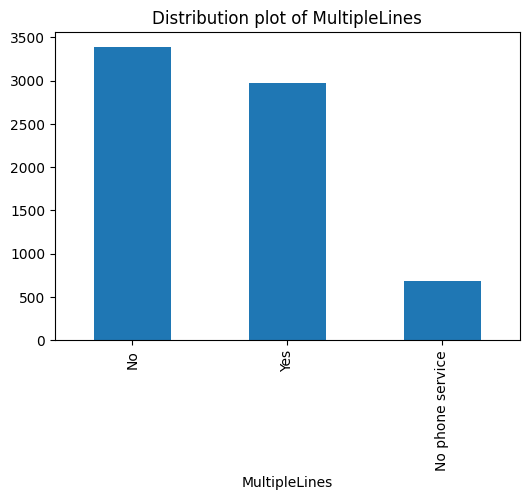

Distribution plot of InternetService


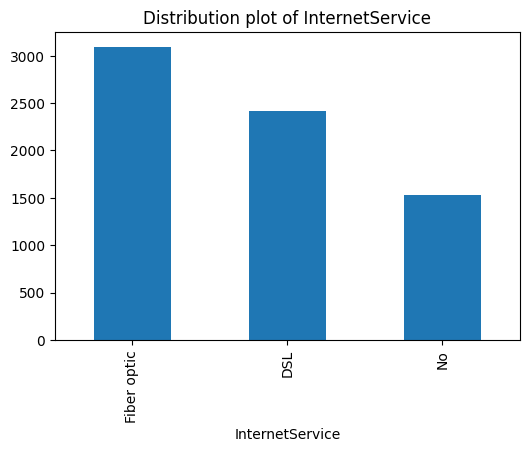

Distribution plot of OnlineSecurity


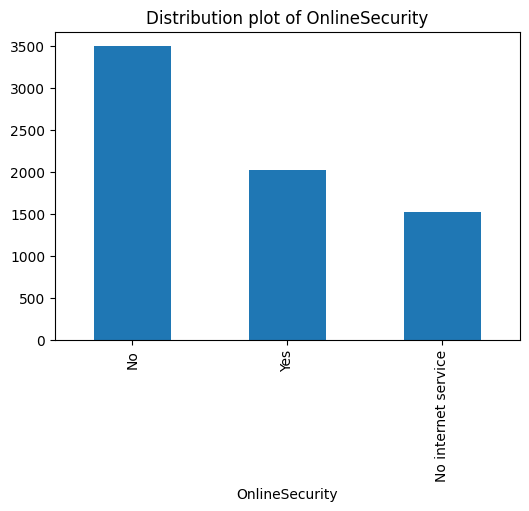

Distribution plot of OnlineBackup


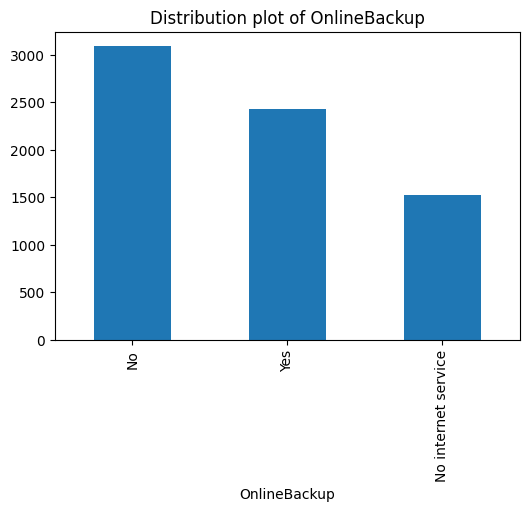

Distribution plot of DeviceProtection


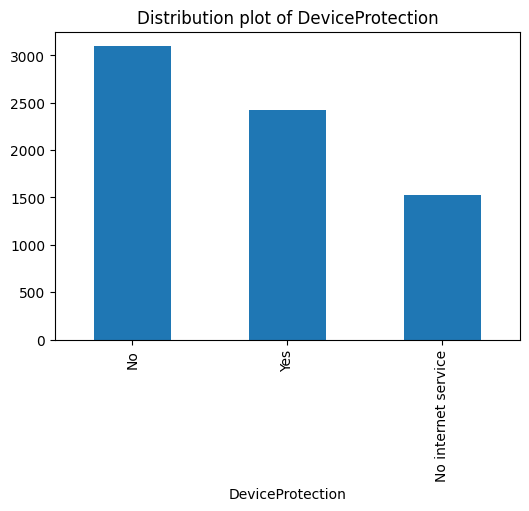

Distribution plot of TechSupport


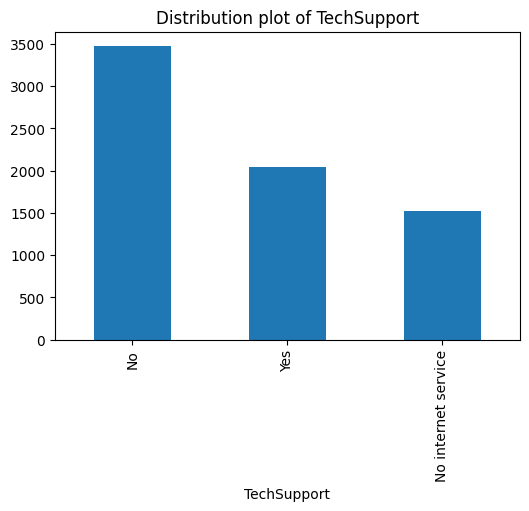

Distribution plot of StreamingTV


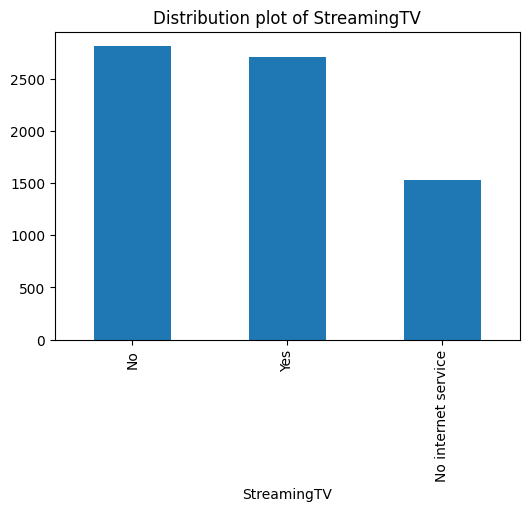

Distribution plot of StreamingMovies


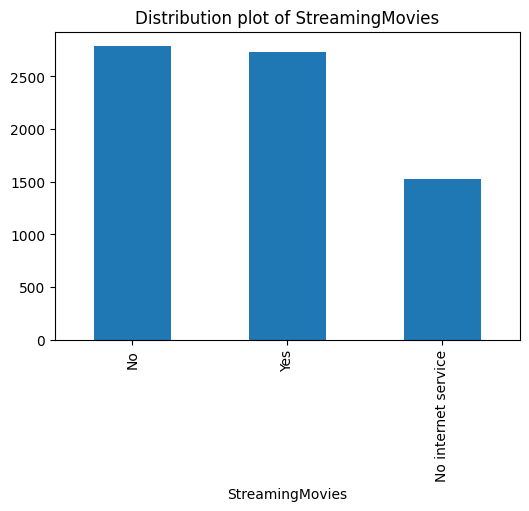

Distribution plot of Contract


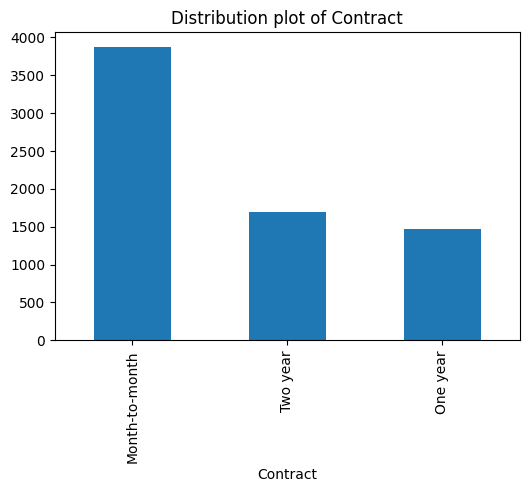

Distribution plot of PaperlessBilling


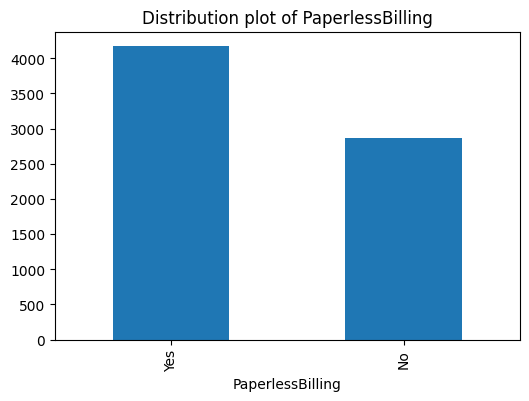

Distribution plot of PaymentMethod


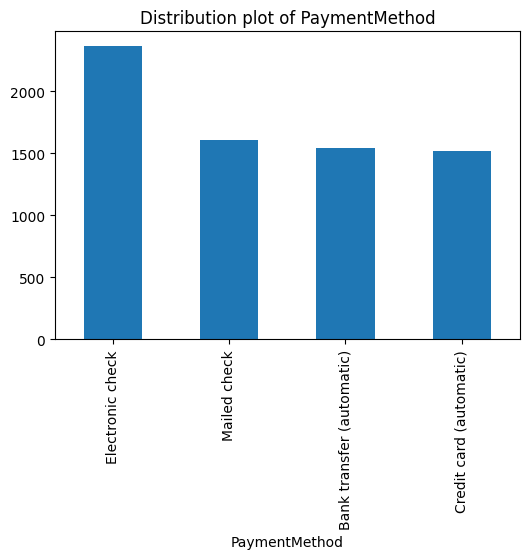

Distribution plot of Churn


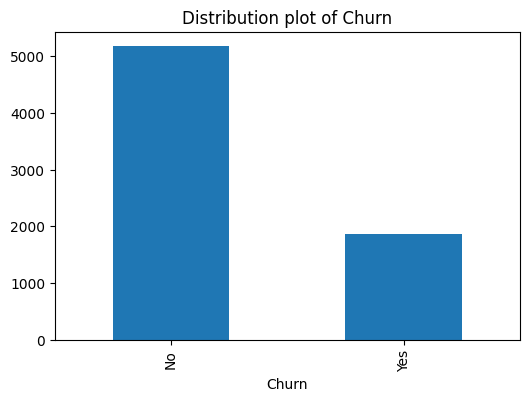

In [132]:
def dist_plot_cat(df, cat_cols):

    for col in cat_cols:
        if df[col].nunique() < 10:
            plt.figure(figsize=(6,4))
            print(f"Distribution plot of {col}")
            df[col].value_counts().plot(kind='bar')
            plt.title(f"Distribution plot of {col}")
            plt.show()

dist_plot_cat(df, cat_cols)

## Bivariate Analysis

Churn vs gender


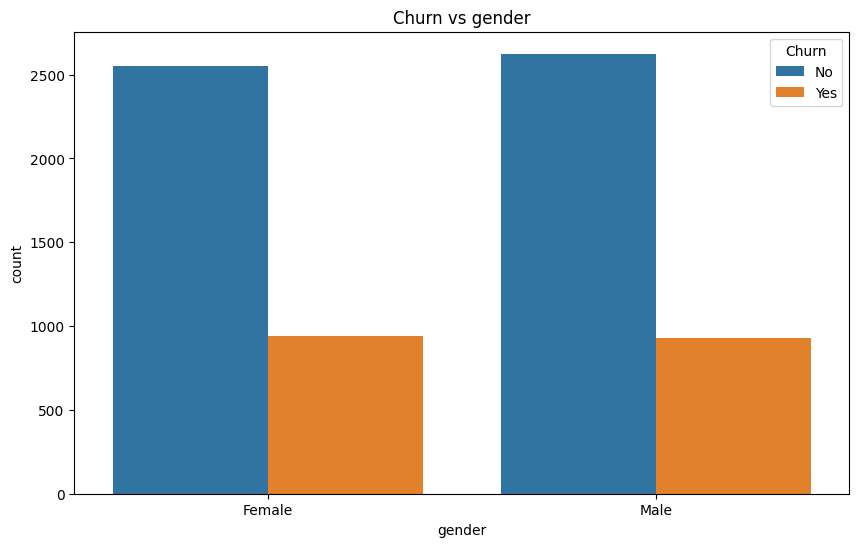

Churn vs Partner


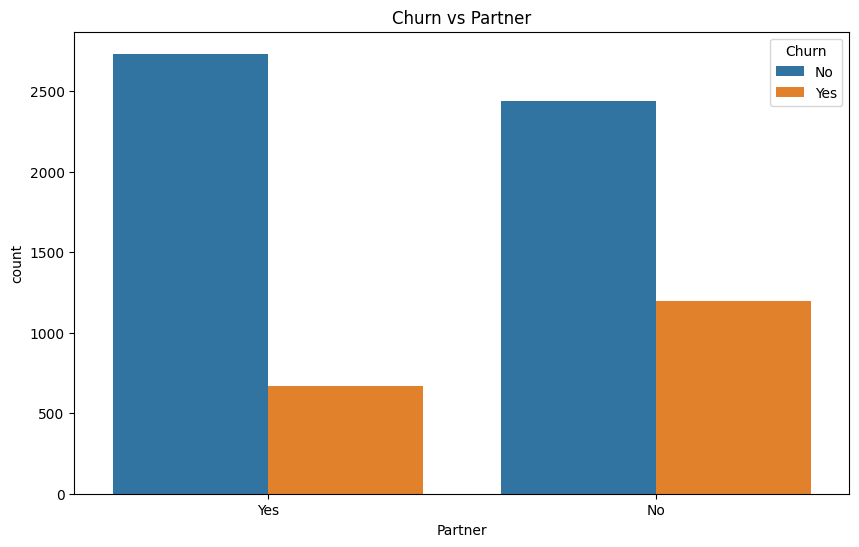

Churn vs Dependents


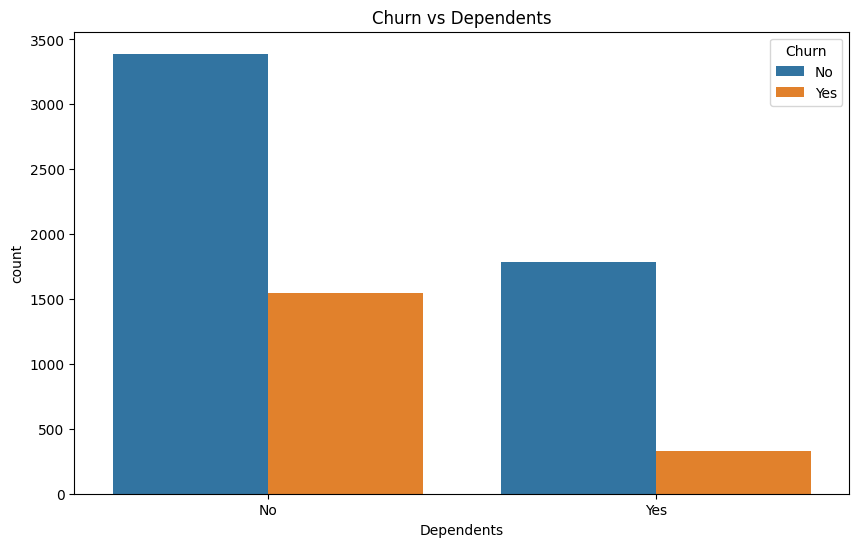

Churn vs PhoneService


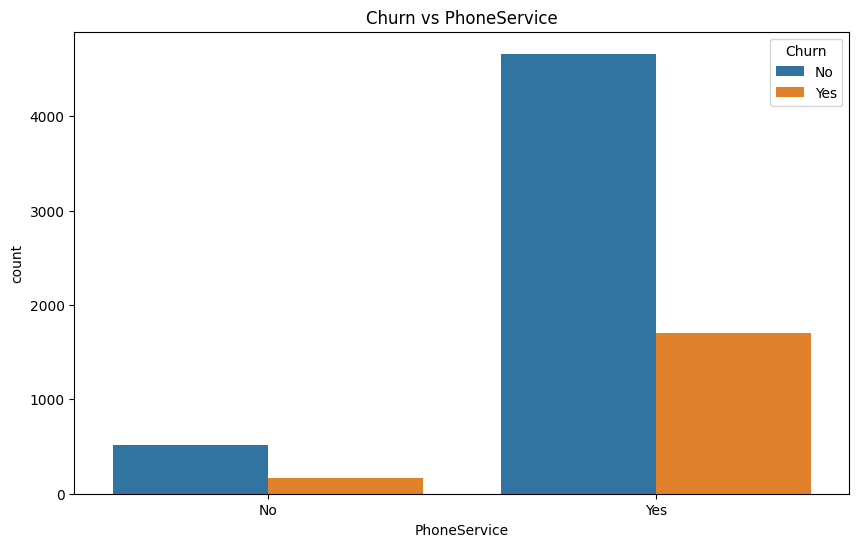

Churn vs MultipleLines


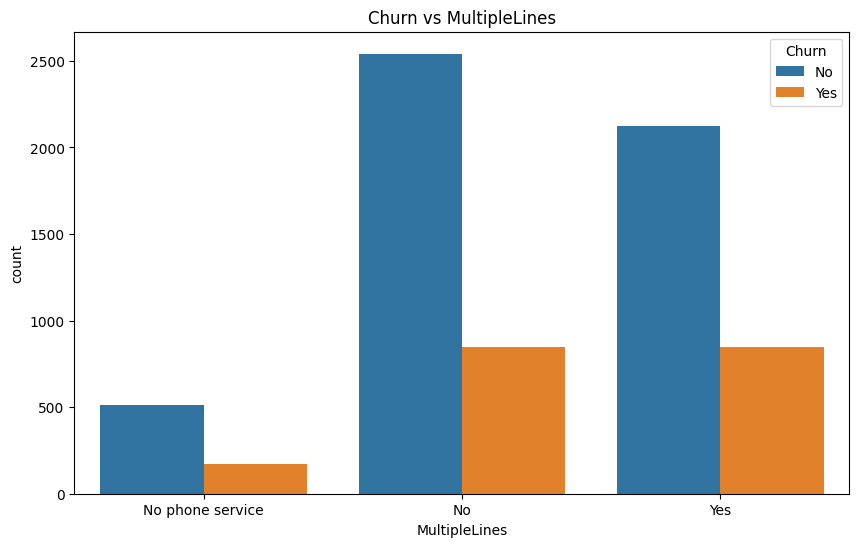

Churn vs InternetService


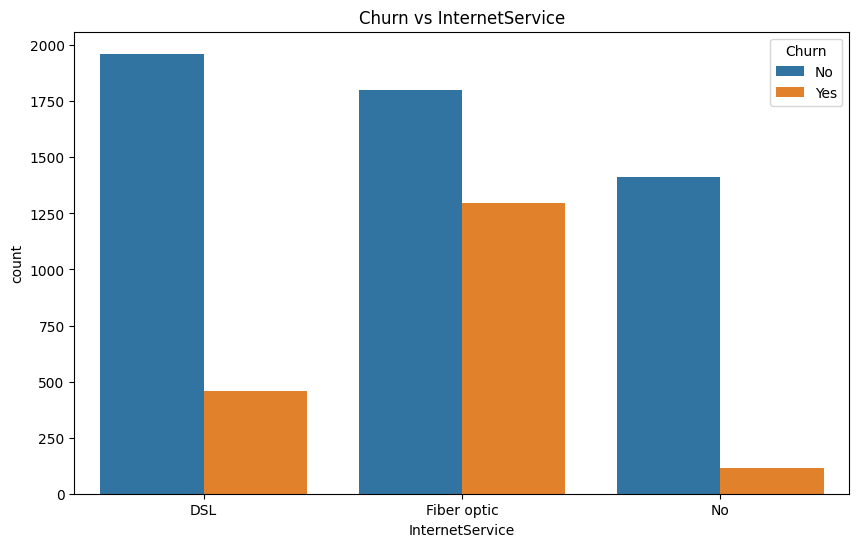

Churn vs OnlineSecurity


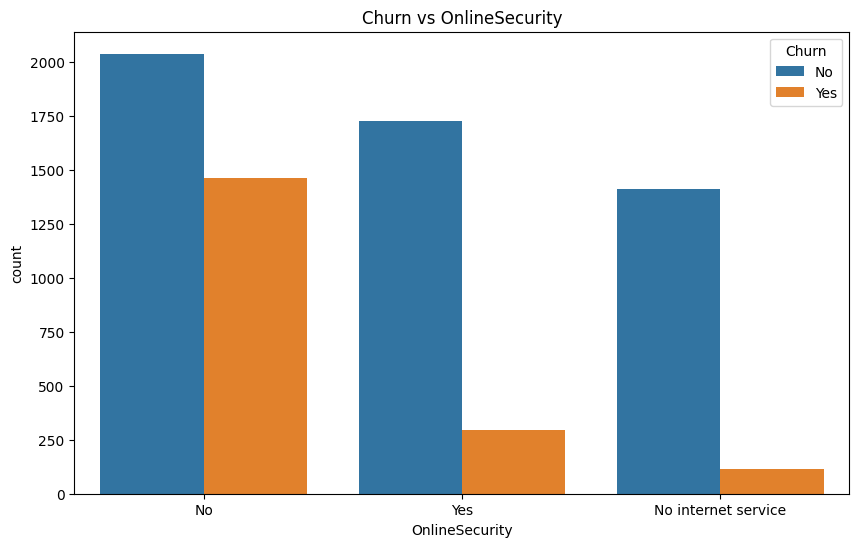

Churn vs OnlineBackup


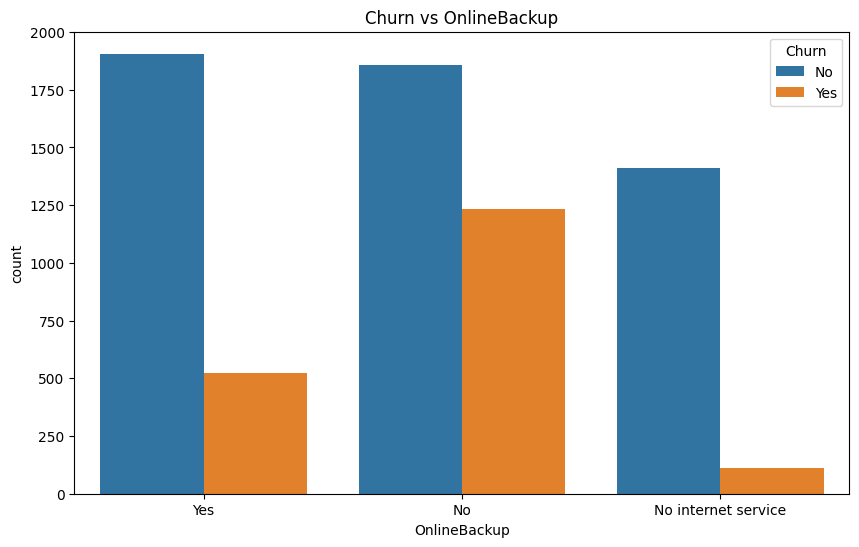

Churn vs DeviceProtection


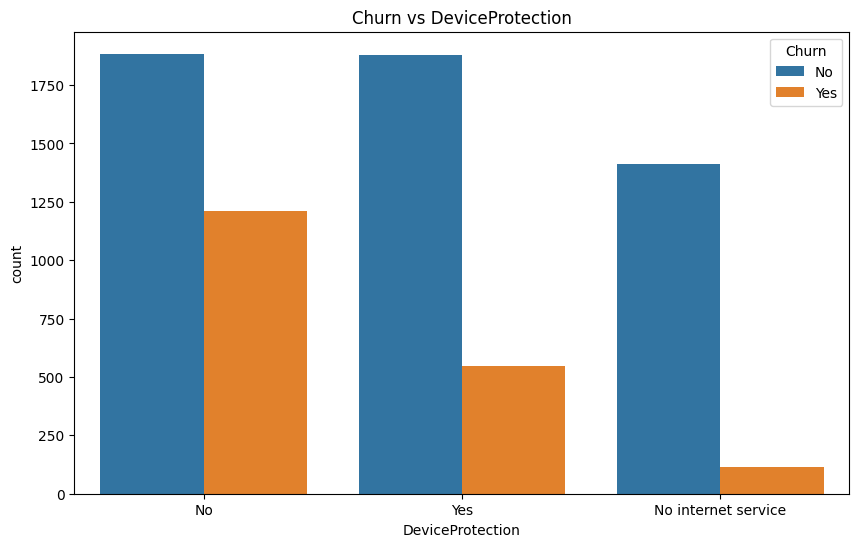

Churn vs TechSupport


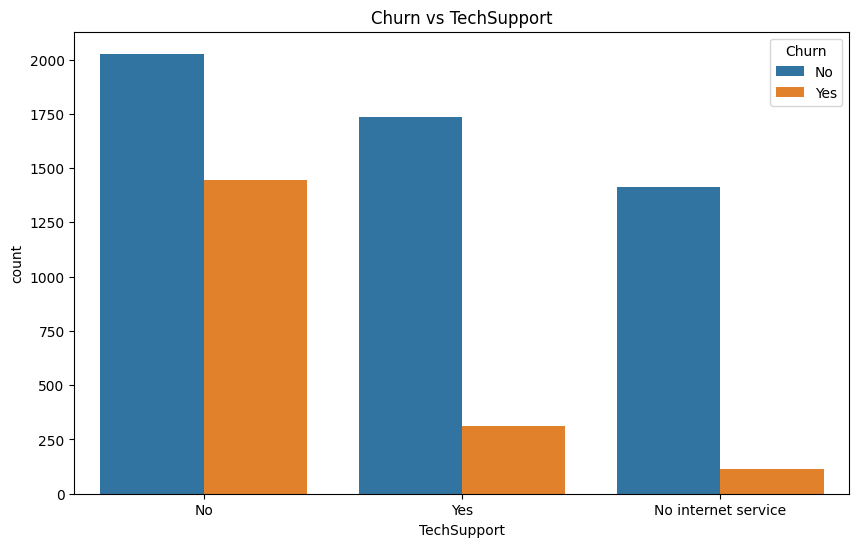

Churn vs StreamingTV


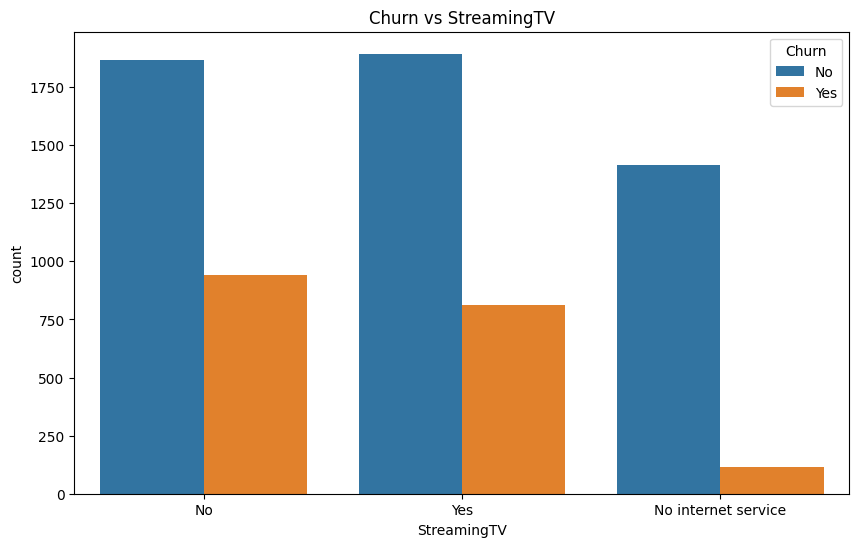

Churn vs StreamingMovies


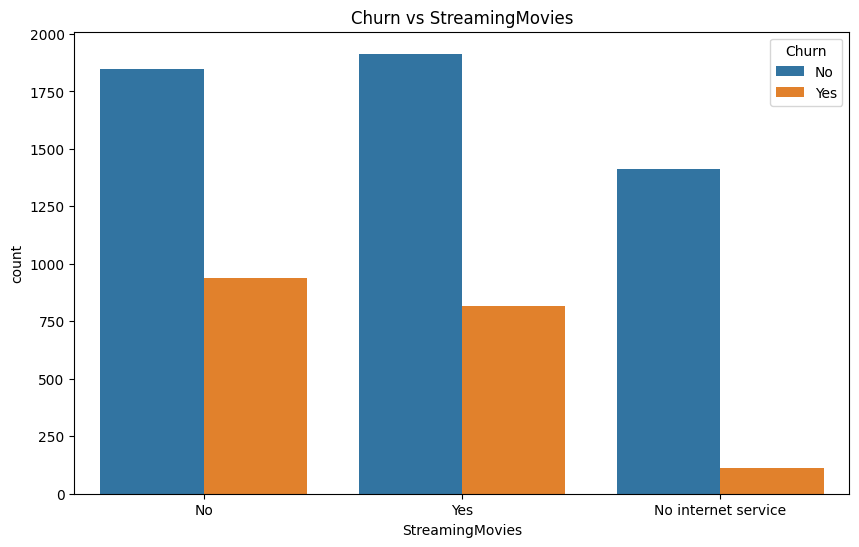

Churn vs Contract


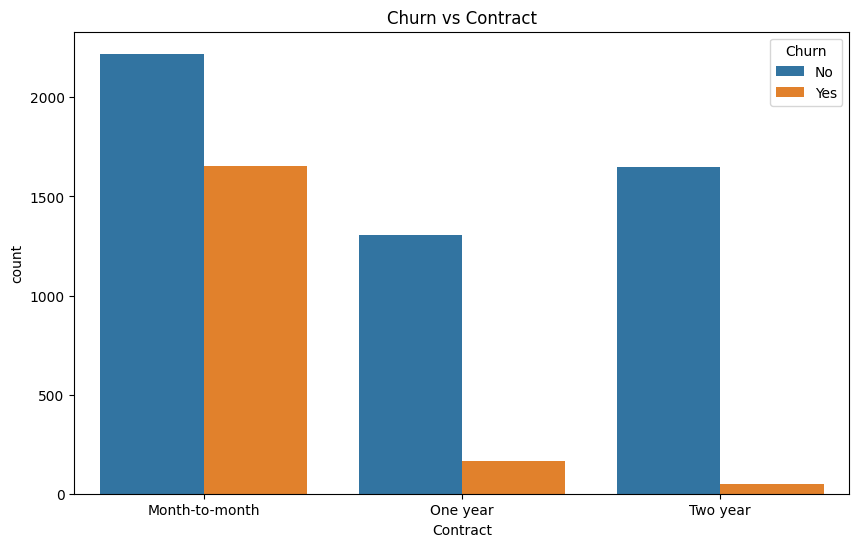

Churn vs PaperlessBilling


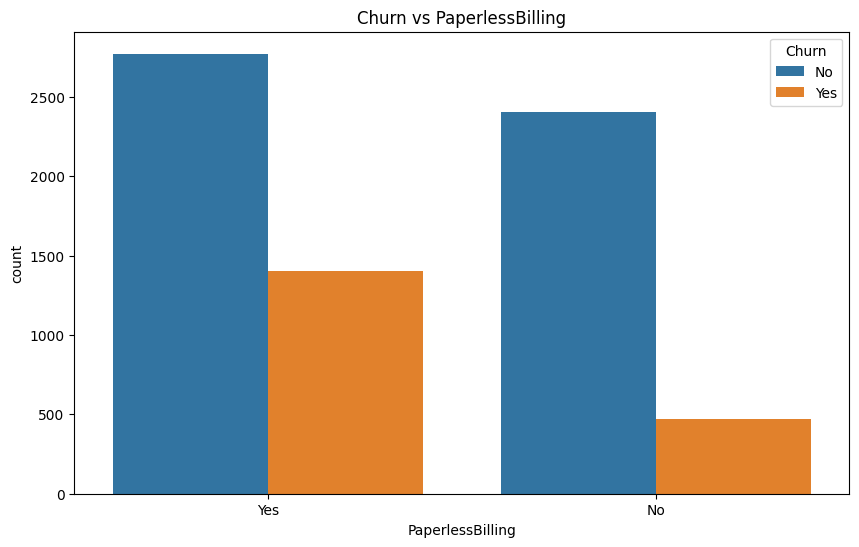

Churn vs PaymentMethod


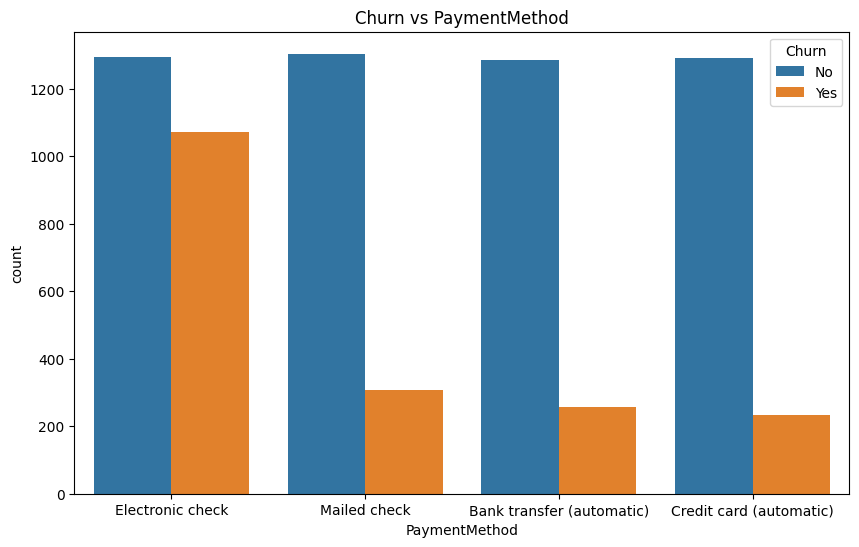

In [133]:
def target_analysis_plot(df, cat_cols, target_col):

    for col in cat_cols:
        if (df[col].nunique() < 10) and (col != target_col):
            plt.figure(figsize=(10,6))
            print(f"{target_col} vs {col}")
            sns.countplot(x=col, hue=target_col, data=df)
            plt.title(f"{target_col} vs {col}")
            plt.show()

target_analysis_plot(df, cat_cols, 'Churn')

In [134]:
# # Compute correlation matrix only for numeric columns
# corr_matrix = df.corr(numeric_only=True)

# # Focus on correlation with Churn
# churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# # Plot heatmap
# plt.figure(figsize=(4, 12))
# sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# plt.title('Correlation of Features with Churn')
# plt.show()

In [135]:
# # Run VIF
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# import pandas as pd
# import numpy as np

# # Remove rows with missing or infinite values
# X = X.replace([np.inf, -np.inf], np.nan)
# X = X.dropna()

# vif_data = pd.DataFrame()
# vif_data['feature'] = X.columns
# vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
# vif_data = vif_data.sort_values(by='VIF', ascending=False)

# print(vif_data)

# Feature Engineering

In [136]:
def cat_cols_category(df, cat_cols):
    for col in cat_cols:
        print(f"{col} ash below categories in it:\n{df[col].unique()}")
        print()

cat_cols_category(df, cat_cols)

gender ash below categories in it:
['Female' 'Male']

Partner ash below categories in it:
['Yes' 'No']

Dependents ash below categories in it:
['No' 'Yes']

PhoneService ash below categories in it:
['No' 'Yes']

MultipleLines ash below categories in it:
['No phone service' 'No' 'Yes']

InternetService ash below categories in it:
['DSL' 'Fiber optic' 'No']

OnlineSecurity ash below categories in it:
['No' 'Yes' 'No internet service']

OnlineBackup ash below categories in it:
['Yes' 'No' 'No internet service']

DeviceProtection ash below categories in it:
['No' 'Yes' 'No internet service']

TechSupport ash below categories in it:
['No' 'Yes' 'No internet service']

StreamingTV ash below categories in it:
['No' 'Yes' 'No internet service']

StreamingMovies ash below categories in it:
['No' 'Yes' 'No internet service']

Contract ash below categories in it:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling ash below categories in it:
['Yes' 'No']

PaymentMethod ash below categories

In [137]:
def map_services_no(df):
    service_cols = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
    ]

    for col in service_cols:
        df[col] = df[col].replace({
            'No internet service': 'No',
            'No phone service': 'No'
        })

map_services_no(df)

In [138]:
def cat_cols_category(df, cat_cols):
    for col in cat_cols:
        print(f"{col} ash below categories in it:\n{df[col].unique()}")
        print()

cat_cols_category(df, cat_cols)

gender ash below categories in it:
['Female' 'Male']

Partner ash below categories in it:
['Yes' 'No']

Dependents ash below categories in it:
['No' 'Yes']

PhoneService ash below categories in it:
['No' 'Yes']

MultipleLines ash below categories in it:
['No' 'Yes']

InternetService ash below categories in it:
['DSL' 'Fiber optic' 'No']

OnlineSecurity ash below categories in it:
['No' 'Yes']

OnlineBackup ash below categories in it:
['Yes' 'No']

DeviceProtection ash below categories in it:
['No' 'Yes']

TechSupport ash below categories in it:
['No' 'Yes']

StreamingTV ash below categories in it:
['No' 'Yes']

StreamingMovies ash below categories in it:
['No' 'Yes']

Contract ash below categories in it:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling ash below categories in it:
['Yes' 'No']

PaymentMethod ash below categories in it:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn ash below categories in it:
['No' 'Yes']



In [139]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [149]:
def get_preprocessor():

    numeric_feat_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('power_transform', PowerTransformer(method='yeo-johnson')),
        ('scaler', StandardScaler())
    ])

    categorical_feat_pipeline = Pipeline(steps=[
        ('ohe_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_feat_pipeline, make_column_selector(dtype_include=['int64','float64'])),
            ('cat', categorical_feat_pipeline, make_column_selector(dtype_include=['object','category']))
        ],
        remainder='drop'
    )

    return preprocessor

In [150]:
def mlflow_exp(df):

    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Telco Customer Churn")

    X = df.drop(columns=['Churn'])
    y = df['Churn']

    le = LabelEncoder()
    y = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "DecisionTree": DecisionTreeClassifier(random_state=23),
        "RandomForest": RandomForestClassifier(random_state=23),
        "LightGBM": LGBMClassifier(random_state=23),
        "XGBoost": XGBClassifier(random_state=23)
    }

    best_score = 0
    best_model = None
    best_model_name = None

    for model_name, model in models.items():
        with mlflow.start_run(run_name=model_name):
            
            preprocessor = get_preprocessor()

            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("model", model)
            ])

            cv_scores = cross_val_score(
                pipeline,
                X_train,
                y_train,
                cv=cv,
                scoring="accuracy"
            )

            mean_cv_score = cv_scores.mean()

            pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict(X_test)

            test_accuracy = accuracy_score(y_test, y_pred)

            mlflow.log_param("model_name", model_name)

            mlflow.log_metric("cv_accuracy", mean_cv_score)
            mlflow.log_metric("test_accuracy", test_accuracy)

            mlflow.sklearn.log_model(
                pipeline,
                artifact_path="model",
                input_example=X_train.iloc[:5]
            )

            print(f"{model_name} logged successfully")

            # Track best model
            if test_accuracy > best_score:
                best_score = test_accuracy
                best_model = pipeline
                best_model_name = model_name

    return best_model, best_model_name, best_score

In [151]:
best_model, best_model_name, best_score = mlflow_exp(df)

2026/03/06 11:54:02 INFO mlflow.tracking.fluent: Experiment with name 'Telco Customer Churn' does not exist. Creating a new experiment.
2026/03/06 11:54:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/06 11:54:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LogisticRegression logged successfully
🏃 View run LogisticRegression at: http://127.0.0.1:5000/#/experiments/1/runs/462a6205cc924e76944d2da5ebe8066f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/03/06 11:54:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/06 11:54:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DecisionTree logged successfully
🏃 View run DecisionTree at: http://127.0.0.1:5000/#/experiments/1/runs/d199b1677b2447dc83ede5940aa456d9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/03/06 11:54:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/06 11:54:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest logged successfully
🏃 View run RandomForest at: http://127.0.0.1:5000/#/experiments/1/runs/2e8abe1543ed44beba1a0977821f04ae
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 655
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000584 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is n

2026/03/06 11:54:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/06 11:54:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM logged successfully
🏃 View run LightGBM at: http://127.0.0.1:5000/#/experiments/1/runs/20ffdbd56cbb4712929e27120139906c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/03/06 11:54:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/06 11:54:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost logged successfully
🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/567a43f457bc4a108e36b2cd626669b8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [ ]:
def tune_logistic_regression_optuna(df):

    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Telco Customer Churn - Logistic Regression Optuna")

    X = df.drop(columns=['Churn'])
    y = df['Churn']

    le = LabelEncoder()
    y = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    def objective(trial):

        C = trial.suggest_float("C", 1e-4, 10, log=True)
        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
        solver = trial.suggest_categorical("solver", ["liblinear", "saga"])
        max_iter = trial.suggest_int("max_iter", 100, 1000)

        model = LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            max_iter=max_iter,
            random_state=23
        )

        pipeline = Pipeline([
            ("preprocessor", get_preprocessor()),
            ("model", model)
        ])

        scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        )

        mean_score = scores.mean()

        with mlflow.start_run(nested=True):
            mlflow.log_param("C", C)
            mlflow.log_param("penalty", penalty)
            mlflow.log_param("solver", solver)
            mlflow.log_param("max_iter", max_iter)
            mlflow.log_metric("cv_auc", mean_score)

        return mean_score


    with mlflow.start_run(run_name="LogisticRegression_Optuna_Tuning") as run:
        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=30)
        best_params = study.best_params

        mlflow.log_params(best_params)

        best_model = LogisticRegression(random_state=42, **best_params)

        pipeline = Pipeline([
            ("preprocessor", get_preprocessor()),
            ("model", best_model)
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        y_prob = pipeline.predict_proba(X_test)[:,1]
        test_auc = roc_auc_score(y_test, y_prob)

        mlflow.log_metric("test_auc", test_auc)
        mlflow.log_metric("best_cv_auc", study.best_value)
        mlflow.log_metric("test_accuracy", accuracy)
        mlflow.log_metric("test_precision", precision)
        mlflow.log_metric("test_recall", recall)
        mlflow.log_metric("test_f1_score", f1)

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(6,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix")
        mlflow.log_figure(plt.gcf(), "confusion_matrix.png")

        # Classification Report
        report_text = classification_report(y_test, y_pred)

        with open("classification_report.txt","w") as f:
            f.write(report_text)

        mlflow.log_artifact("classification_report.txt")
        mlflow.sklearn.log_model(
                    pipeline,
                    artifact_path="best_model"
                )

        print("Best Params:", best_params)

    run_id = run.info.run_id
    return study, run_id

In [161]:
study, run_id = tune_logistic_regression_optuna(df)

2026/03/06 12:21:42 INFO mlflow.tracking.fluent: Experiment with name 'Telco Customer Churn - Logistic Regression Optuna' does not exist. Creating a new experiment.


[I 2026-03-06 12:21:42,524] A new study created in memory with name: no-name-2bb212bf-bc3d-4f50-8eaa-2e8282cb6151
[I 2026-03-06 12:21:42,840] Trial 0 finished with value: 0.8457364653446557 and parameters: {'C': 0.0026523026987679416, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 291}. Best is trial 0 with value: 0.8457364653446557.


🏃 View run treasured-duck-979 at: http://127.0.0.1:5000/#/experiments/3/runs/873eb5598eb347b9aef700d9a700eb5b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


[I 2026-03-06 12:21:43,143] Trial 1 finished with value: 0.5 and parameters: {'C': 0.0002309939660066714, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 807}. Best is trial 0 with value: 0.8457364653446557.


🏃 View run unruly-gnu-900 at: http://127.0.0.1:5000/#/experiments/3/runs/06528e2c086f465587d9454c1f05ac63
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


...

🏃 View run worried-jay-692 at: http://127.0.0.1:5000/#/experiments/3/runs/a5e4f0184c5f475d8135302643e66294
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


[I 2026-03-06 12:22:02,387] Trial 29 finished with value: 0.8495823710737204 and parameters: {'C': 0.0821274186044889, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 477}. Best is trial 22 with value: 0.8503589883082343.
2026/03/06 12:22:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run redolent-roo-230 at: http://127.0.0.1:5000/#/experiments/3/runs/7952c8d2461644389212e18c59741a5c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


2026/03/06 12:22:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best Params: {'C': 0.3529871100631915, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 464}
🏃 View run LogisticRegression_Optuna_Tuning at: http://127.0.0.1:5000/#/experiments/3/runs/d8770b43ae184e4eb372b2ba83e7b9dc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [ ]:
model_uri = f"runs:/{run_id}/best_model"

mlflow.register_model(
    model_uri=model_uri,
    name="TelcoCustomerChurnModel"
)

In [ ]:
client = MlflowClient()

client.transition_model_version_stage(
    name="TelcoCustomerChurnModel",
    version=1,
    stage="Production"
)

In [ ]:
# When deploying the API you load the production model automatically.
model = mlflow.pyfunc.load_model(
    "models:/TelcoCustomerChurnModel/Production"
)
# Always use latest production model. Your API doesn't need to change when new models are deployed.